# Empirical Analysis: Employment Prevalence Under Age Distribution Shift

This notebook reproduces the ACS analysis from the paper. We train a logistic regression
on ACS employment data, calibrate it with Isotonic Regression and MCGrad, then measure
prevalence estimation bias under synthetic age distribution shift.

In [ ]:
import os

import numpy as np
import pandas as pd
from sklearn import metrics as skmetrics
from sklearn.model_selection import train_test_split
from mcgrad import metrics, methods, plotting
import matplotlib.pyplot as plt

from helpers import (
    BINARY_COLUMNS,
    CATEGORICAL_COLUMNS,
    LABEL_COLUMN,
    NUMERICAL_COLUMNS,
    configure_logging,
    create_logistic_pipeline,
    load_acs_employment_data,
    setup_plotting,
    compute_rogan_gladen_estimate,
    estimate_classifier_error_rates,
    calibrate_threshold_prevalence_matching,
    sld_estimate,
    pacc_estimate,
    compute_all_prevalence_estimates,
    compute_bootstrap_mse,
    compute_bias_table,
    resample_with_age_shift,
)

os.makedirs('../paper/images', exist_ok=True)
setup_plotting()
configure_logging()

## 1. Data Loading

In [2]:
# Load data from multiple states and years for more robust analysis
# Training states: Large, geographically diverse states
# OOD states: Held out for out-of-distribution evaluation

TRAIN_STATES = ["TX", "MI", "PA", "OH", "IL", "GA", "NC", "VA"]
OOD_STATES = ["CA", "NY", "FL", "WA", "AZ", "CO"]

# Use multiple survey years for more data
SURVEY_YEARS = ["2016", "2017", "2018"]

print(f"Loading training data: {len(TRAIN_STATES)} states x {len(SURVEY_YEARS)} years...")
train_source_df = load_acs_employment_data(
    states=TRAIN_STATES, 
    survey_years=SURVEY_YEARS,
    include_state=True,
    include_year=True,
)
print(f"Training states: {len(train_source_df)} total samples")
print(f"  By state: {train_source_df['STATE'].value_counts().to_dict()}")
print(f"  By year: {train_source_df['YEAR'].value_counts().to_dict()}")

print(f"\nLoading OOD data: {len(OOD_STATES)} states x {len(SURVEY_YEARS)} years...")
ood_df = load_acs_employment_data(
    states=OOD_STATES, 
    survey_years=SURVEY_YEARS,
    include_state=True,
    include_year=True,
)
print(f"OOD states: {len(ood_df)} total samples")
print(f"  By state: {ood_df['STATE'].value_counts().to_dict()}")

Loading training data: 8 states x 3 years...


Dataset has 3066049 samples
Training states: 3066049 total samples
  By state: {'TX': 795838, 'PA': 383769, 'IL': 379272, 'OH': 355354, 'NC': 303352, 'GA': 298718, 'MI': 297023, 'VA': 252723}
  By year: {2018: 1030260, 2017: 1023512, 2016: 1012277}

Loading OOD data: 6 states x 3 years...


Dataset has 2917368 samples
OOD states: 2917368 total samples
  By state: {'CA': 1132427, 'FL': 598632, 'NY': 589656, 'WA': 223303, 'AZ': 207251, 'CO': 166099}


## 2. Model Training and Calibration

In [3]:
# Split training data into train/calibration and held-out test sets
from sklearn.model_selection import train_test_split

# Stratify by both label and state to ensure balanced representation
train_df, test_df = train_test_split(
    train_source_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=train_source_df[[LABEL_COLUMN, "STATE"]].apply(tuple, axis=1)
)

# Further split train into model training and calibration sets
model_train_df, calibration_df = train_test_split(
    train_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=train_df[[LABEL_COLUMN, "STATE"]].apply(tuple, axis=1)
)

print(f"Model training set: {len(model_train_df):,} samples")
print(f"Calibration set: {len(calibration_df):,} samples")
print(f"In-distribution test set: {len(test_df):,} samples")
print(f"\nState distribution in test set:")
print(test_df["STATE"].value_counts().to_dict())

Model training set: 1,502,363 samples
Calibration set: 643,871 samples
In-distribution test set: 919,815 samples

State distribution in test set:
{'TX': 238752, 'PA': 115131, 'IL': 113781, 'OH': 106607, 'NC': 91005, 'GA': 89616, 'MI': 89106, 'VA': 75817}


In [4]:
# Train the base logistic regression model
# Exclude STATE and YEAR from features (they're for segmentation analysis, not prediction)
feature_cols = [c for c in model_train_df.columns if c not in [LABEL_COLUMN, "STATE", "YEAR"]]

X_train = model_train_df[feature_cols]
y_train = model_train_df[LABEL_COLUMN].astype(int).to_numpy()

logistic_pipeline = create_logistic_pipeline()
logistic_pipeline.fit(X_train, y_train)
print(f"Base model trained on {len(feature_cols)} features")

Base model trained on 16 features


In [5]:
# Generate base model predictions for all datasets
BASE_MODEL_COL = 'base_model_prediction'

for df in [calibration_df, test_df, ood_df]:
    # Use only the feature columns (exclude STATE, YEAR, and label)
    X = df[[c for c in df.columns if c not in [LABEL_COLUMN, "STATE", "YEAR"]]]
    df[BASE_MODEL_COL] = logistic_pipeline.predict_proba(X)[:, 1]

print("Base model predictions generated for all datasets")

Base model predictions generated for all datasets


In [ ]:
# Fit calibration methods on the calibration set

# 1. Isotonic Regression (global calibration)
isotonic_regression = methods.IsotonicRegression().fit(
    calibration_df,
    BASE_MODEL_COL,
    LABEL_COLUMN,
)
print("Isotonic regression fitted")

# 2. MCGrad (multicalibration)
categorical_segment_features = CATEGORICAL_COLUMNS + BINARY_COLUMNS
numerical_segment_features = NUMERICAL_COLUMNS

mcgrad = methods.MCGrad(save_training_performance=True)
mcgrad = mcgrad.fit(
    calibration_df,
    BASE_MODEL_COL,
    LABEL_COLUMN,
    categorical_feature_column_names=categorical_segment_features,
    numerical_feature_column_names=numerical_segment_features,
)
print("MCGrad fitted")

In [7]:
# Generate calibrated predictions for all evaluation datasets
IR_COL = 'isotonic_prediction'
MCGRAD_COL = 'mcgrad_prediction'

for df in [test_df, ood_df]:
    # Isotonic regression predictions
    df[IR_COL] = isotonic_regression.predict(df, BASE_MODEL_COL)
    
    # MCGrad predictions
    df[MCGRAD_COL] = mcgrad.predict(
        df=df,
        prediction_column_name=BASE_MODEL_COL,
        categorical_feature_column_names=categorical_segment_features,
        numerical_feature_column_names=numerical_segment_features,
    )

print("Calibrated predictions generated")

[INFO][2026-03-02 09:42:21][methods.py:550]: Preprocessing input data with 919815 rows; in_fit_phase = False


[INFO][2026-03-02 09:42:29][methods.py:550]: Preprocessing input data with 2917368 rows; in_fit_phase = False


Calibrated predictions generated


### MCGrad Fit Evaluation

Learning curve showing training and validation loss across MCGrad boosting rounds,
followed by discriminative performance (PRAUC, ROCAUC, log-loss) and calibration
metrics (ECCE, MCE) comparing the base model, isotonic regression, and MCGrad.

In [ ]:
# === MCGrad Fit Evaluation ===

# Learning curve: training and validation loss across MCGrad rounds
plotting.plot_learning_curve(mcgrad, show_all=True).update_layout(
    width=700, height=500, title="MCGrad Learning Curve"
).show()

# Discriminative and calibration metrics: base model vs isotonic regression vs MCGrad
eval_metric_fns = {
    "PRAUC": skmetrics.average_precision_score,
    "ROCAUC": skmetrics.roc_auc_score,
    "Log-loss": skmetrics.log_loss,
}

score_columns = {
    "Base Model": BASE_MODEL_COL,
    "Isotonic Regression": IR_COL,
    "MCGrad": MCGRAD_COL,
}

eval_results = {}
for name, col in score_columns.items():
    row = {
        metric_name: metric_func(test_df[LABEL_COLUMN].values, test_df[col].values)
        for metric_name, metric_func in eval_metric_fns.items()
    }
    ecce_val = metrics.ecce(test_df[LABEL_COLUMN].values, test_df[col].values)
    ecce_sig = metrics.ecce_sigma(test_df[LABEL_COLUMN].values, test_df[col].values)
    mce_obj = metrics.MulticalibrationError(
        df=test_df,
        label_column=LABEL_COLUMN,
        score_column=col,
        categorical_segment_columns=CATEGORICAL_COLUMNS + BINARY_COLUMNS,
        numerical_segment_columns=NUMERICAL_COLUMNS,
    )
    row["ECCE"] = ecce_val
    row["ECCE σ"] = ecce_sig
    row["MCE"] = mce_obj.mce
    row["MCE σ"] = mce_obj.mce_sigma
    eval_results[name] = row

pd.DataFrame(eval_results).T.round(4)

In [8]:
# Calibrate threshold and estimate TPR/FPR from calibration set

# Use prevalence-matching threshold: ensures Classify & Count is unbiased on calibration distribution
THRESHOLD = calibrate_threshold_prevalence_matching(
    labels=calibration_df[LABEL_COLUMN],
    predictions=calibration_df[BASE_MODEL_COL],
)
print(f"Calibrated threshold (prevalence-matching): {THRESHOLD:.4f}")
print(f"  (vs naive 0.5 threshold)")

# Estimate TPR and FPR at calibrated threshold for Rogan-Gladen
calibration_tpr, calibration_fpr = estimate_classifier_error_rates(
    labels=calibration_df[LABEL_COLUMN],
    predictions=calibration_df[BASE_MODEL_COL],
    threshold=THRESHOLD,
)

print(f"\nCalibration set error rates at threshold={THRESHOLD:.4f}:")
print(f"  TPR (sensitivity): {calibration_tpr:.4f}")
print(f"  FPR (1-specificity): {calibration_fpr:.4f}")

# PACC calibration parameters: E[h(X)|Y=1] and E[h(X)|Y=0] using continuous scores
PACC_POS_MEAN = calibration_df[calibration_df[LABEL_COLUMN] == 1][BASE_MODEL_COL].mean()
PACC_NEG_MEAN = calibration_df[calibration_df[LABEL_COLUMN] == 0][BASE_MODEL_COL].mean()
SOURCE_PREVALENCE = calibration_df[LABEL_COLUMN].mean()

print(f"\nPACC parameters (soft-score Rogan-Gladen):")
print(f"  E[h(X)|Y=1]: {PACC_POS_MEAN:.4f}")
print(f"  E[h(X)|Y=0]: {PACC_NEG_MEAN:.4f}")
print(f"\nSource prevalence for SLD: {SOURCE_PREVALENCE:.4f}")

# Verify: at this threshold, apparent prevalence should match true prevalence
apparent_prev = (calibration_df[BASE_MODEL_COL] >= THRESHOLD).mean()
true_prev = calibration_df[LABEL_COLUMN].mean()
print(f"\nVerification:")
print(f"  True prevalence in calibration set: {true_prev:.4f}")
print(f"  Apparent prevalence at calibrated threshold: {apparent_prev:.4f}")

Calibrated threshold (prevalence-matching): 0.5667
  (vs naive 0.5 threshold)

Calibration set error rates at threshold=0.5667:
  TPR (sensitivity): 0.7821
  FPR (1-specificity): 0.1811

PACC parameters (soft-score Rogan-Gladen):
  E[h(X)|Y=1]: 0.6979
  E[h(X)|Y=0]: 0.2516

Source prevalence for SLD: 0.4539

Verification:
  True prevalence in calibration set: 0.4539
  Apparent prevalence at calibrated threshold: 0.4539


## 3. Prevalence Estimation Under Synthetic Age Distribution Shift

We create synthetic target populations by resampling with different age distributions,
then compare prevalence estimation bias across methods.

In [ ]:
import sys
sys.path.insert(0, "..")
from plot_config import METHOD_COLORS

# Methods to compare
methods_to_plot = ["Raw Scores", "Classify & Count", "Rogan-Gladen", "PACC",
                   "SLD (EMQ)", "Isotonic Regression", "MCGrad"]

# Use shared color palette
colors_map = {m: METHOD_COLORS[m] for m in methods_to_plot}

In [ ]:
# --- IPW baseline ---
from sklearn.linear_model import LogisticRegression as LR_IPW

ALL_FEATURE_COLS = NUMERICAL_COLUMNS + BINARY_COLUMNS + CATEGORICAL_COLUMNS

def ipw_estimate(cal_df, target_df, label_col=LABEL_COLUMN, features=ALL_FEATURE_COLS,
                 max_cal_samples=50_000):
    """Importance-weighted prevalence estimation via density ratio.
    
    Standard covariate-shift method: trains logistic regression to distinguish
    source from target, reweights source labels. Requires re-estimation per target.
    
    Subsamples calibration data to max_cal_samples for computational efficiency
    when the calibration set is very large (logistic regression converges well
    before 640K rows).
    """
    if max_cal_samples and len(cal_df) > max_cal_samples:
        cal_sub = cal_df.sample(n=max_cal_samples, random_state=42)
    else:
        cal_sub = cal_df
    combined = pd.concat([
        cal_sub[features].assign(_is_target=0),
        target_df[features].assign(_is_target=1),
    ], ignore_index=True)
    X = pd.get_dummies(combined[features], columns=CATEGORICAL_COLUMNS, drop_first=True).values.astype(float)
    z = combined['_is_target'].values
    clf = LR_IPW(max_iter=1000, random_state=42)
    clf.fit(X, z)
    n_cal = len(cal_sub)
    p_target = clf.predict_proba(X[:n_cal])[:, 1]
    weights = p_target / np.maximum(1 - p_target, 1e-10)
    y = cal_sub[label_col].values
    return np.clip(np.average(y, weights=weights), 0.0, 1.0)

# NOTE: IPW added to methods_to_plot AFTER all IPW estimates are computed.

In [ ]:
# Create synthetic populations by resampling with different age distributions
# We use the test_df which already has all prediction columns

# Define the synthetic scenarios
age_shifts = {
    "Original": "original",
    "Young-skewed": "young",
    "Old-skewed": "old",
    "Bimodal (young+old)": "bimodal",
}

# Generate synthetic populations from the IN-DISTRIBUTION test set
synthetic_populations = {}
for label, shift in age_shifts.items():
    synthetic_populations[label] = resample_with_age_shift(test_df, shift=shift)

# Print true employment rates
for label, syn_df in synthetic_populations.items():
    print(f"{label}: n={len(syn_df):,}, true employment rate = {syn_df[LABEL_COLUMN].mean():.1%}, "
          f"mean age = {syn_df['AGEP'].mean():.1f}")

In [11]:
# Compute prevalence estimates for each synthetic population
synthetic_results = {}

for scenario_label, syn_df in synthetic_populations.items():
    estimates = compute_all_prevalence_estimates(
        target_df=syn_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        pacc_pos_mean=PACC_POS_MEAN,
        pacc_neg_mean=PACC_NEG_MEAN,
        source_prevalence=SOURCE_PREVALENCE,
        threshold=THRESHOLD,
    )
    synthetic_results[scenario_label] = estimates
    print(f"\n{scenario_label}:")
    print(f"  True prevalence: {estimates['True Prevalence']:.4f}")
    display(compute_bias_table(estimates).round(4))


Original:
  True prevalence: 0.4595


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4564,-0.0031,-0.6785
Classify & Count,0.4588,-0.0007,-0.1523
Rogan-Gladen,0.4621,0.0026,0.5574
PACC,0.4588,-0.0007,-0.1581
SLD (EMQ),0.4596,0.0001,0.0122
Isotonic Regression,0.4565,-0.0030,-0.6610
MCGrad,0.4568,-0.0027,-0.5853



Young-skewed:
  True prevalence: 0.1282


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.1475,0.0193,15.0520
Classify & Count,0.1529,0.0247,19.2278
Rogan-Gladen,0.0000,-0.1282,-100.0000
PACC,0.0000,-0.1282,-100.0000
SLD (EMQ),0.0087,-0.1195,-93.1781
Isotonic Regression,0.1486,0.0204,15.9349
MCGrad,0.1271,-0.0011,-0.8650



Old-skewed:
  True prevalence: 0.1676


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.2399,0.0723,43.0979
Classify & Count,0.1014,-0.0662,-39.5169
Rogan-Gladen,0.0000,-0.1676,-100.0000
PACC,0.0000,-0.1676,-100.0000
SLD (EMQ),0.0000,-0.1676,-99.9987
Isotonic Regression,0.2341,0.0665,39.6642
MCGrad,0.1699,0.0022,1.3367



Bimodal (young+old):
  True prevalence: 0.2109


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.2566,0.0457,21.6629
Classify & Count,0.1960,-0.0150,-7.1107
Rogan-Gladen,0.0248,-0.1862,-88.2582
PACC,0.0113,-0.1997,-94.6577
SLD (EMQ),0.0496,-0.1614,-76.4917
Isotonic Regression,0.2543,0.0433,20.5363
MCGrad,0.2121,0.0012,0.5663


Computing bootstrap RMSE (200 resamples per scenario)...
  Original (in-dist)...


  Original (OOD)...


  Young-skewed (in-dist)...


  Young-skewed (OOD)...


  Old-skewed (in-dist)...


  Old-skewed (OOD)...


  Bimodal (young+old) (in-dist)...


  Bimodal (young+old) (OOD)...


Done.


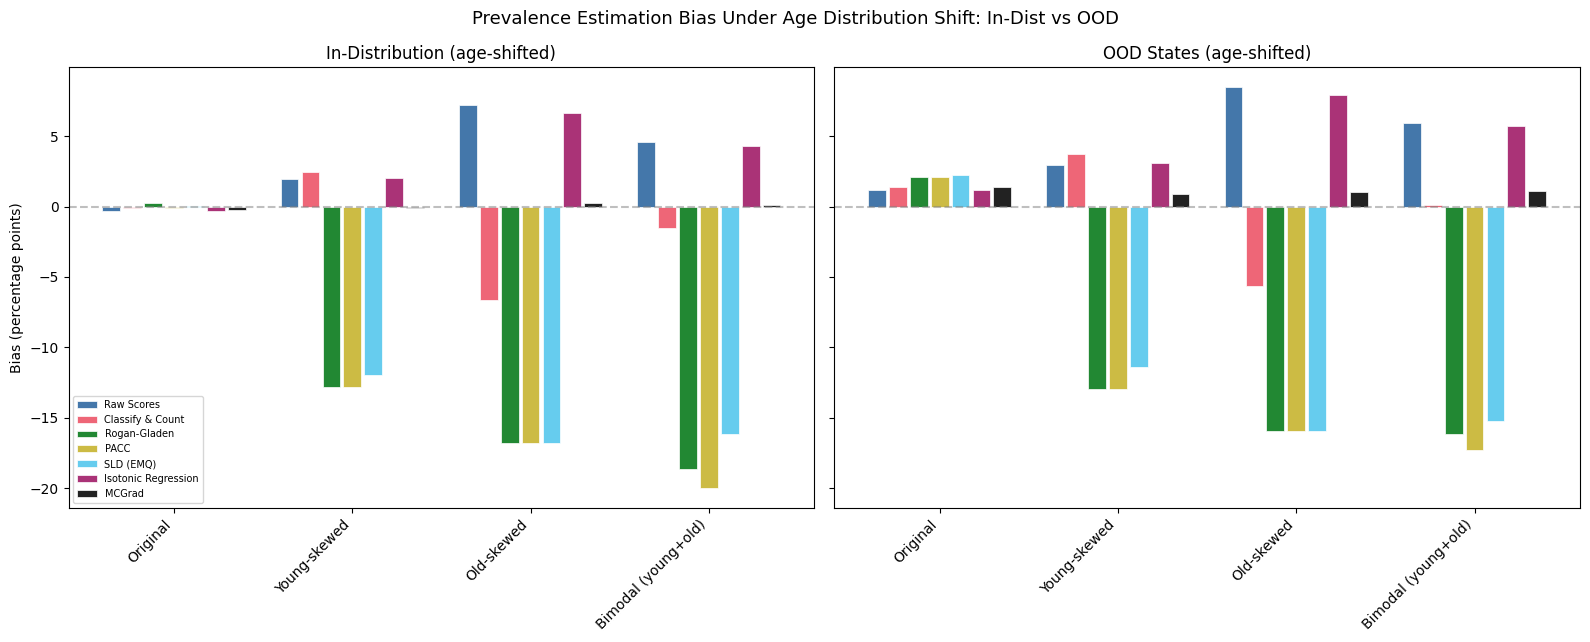

In [12]:
# Repeat on OOD data: synthetic age shifts applied to held-out states
# This combines distribution shift on TWO axes: geography (OOD states) AND age

synthetic_populations_ood = {}
for label, shift in age_shifts.items():
    synthetic_populations_ood[label] = resample_with_age_shift(ood_df, shift=shift)

synthetic_results_ood = {}
for scenario_label, syn_df in synthetic_populations_ood.items():
    estimates = compute_all_prevalence_estimates(
        target_df=syn_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        pacc_pos_mean=PACC_POS_MEAN,
        pacc_neg_mean=PACC_NEG_MEAN,
        source_prevalence=SOURCE_PREVALENCE,
        threshold=THRESHOLD,
    )
    synthetic_results_ood[scenario_label] = estimates

# Bootstrap RMSE computation
print("Computing bootstrap RMSE (200 resamples per scenario)...")
bootstrap_results = {}
bootstrap_results_ood = {}
for label, shift in age_shifts.items():
    print(f"  {label} (in-dist)...")
    bootstrap_results[label] = compute_bootstrap_mse(
        test_df, shift, BASE_MODEL_COL, IR_COL, MCGRAD_COL, LABEL_COLUMN,
        calibration_tpr, calibration_fpr, PACC_POS_MEAN, PACC_NEG_MEAN,
        SOURCE_PREVALENCE, THRESHOLD,
    )
    print(f"  {label} (OOD)...")
    bootstrap_results_ood[label] = compute_bootstrap_mse(
        ood_df, shift, BASE_MODEL_COL, IR_COL, MCGRAD_COL, LABEL_COLUMN,
        calibration_tpr, calibration_fpr, PACC_POS_MEAN, PACC_NEG_MEAN,
        SOURCE_PREVALENCE, THRESHOLD,
    )
print("Done.")

# Save figure for paper (matplotlib) — bias bar chart
scenarios = list(synthetic_results.keys())

fig_mpl, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)

x = np.arange(len(scenarios))
n_methods = len(methods_to_plot)
group_width = 0.82
bar_width = group_width / n_methods * 0.85  # leave ~15% for gaps

for panel_idx, (ax, results, title) in enumerate([
    (ax1, synthetic_results, "In-Distribution (age-shifted)"),
    (ax2, synthetic_results_ood, "OOD States (age-shifted)"),
]):
    for i, method in enumerate(methods_to_plot):
        biases = [(results[s][method] - results[s]["True Prevalence"]) * 100
                  for s in scenarios]
        offset = (i - n_methods / 2 + 0.5) * (group_width / n_methods)
        bars = ax.bar(x + offset, biases, bar_width, label=method,
                      color=colors_map[method], edgecolor="white", linewidth=0.5)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=45, ha="right")
    if panel_idx == 0:
        ax.set_ylabel("Bias (percentage points)")

ax1.legend(fontsize=7, loc="lower left")
fig_mpl.suptitle("Prevalence Estimation Bias Under Age Distribution Shift: In-Dist vs OOD", fontsize=13)
fig_mpl.tight_layout()
fig_mpl.savefig("../paper/images/figure2_acs_age_shift.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Compute ALL IPW estimates (in-dist + OOD) and bootstrap
# This runs after the main results and bootstrap are complete.

print("Computing IPW point estimates...")
for label, syn_df in synthetic_populations.items():
    ipw_est = ipw_estimate(calibration_df, syn_df)
    synthetic_results[label]['IPW'] = ipw_est
    true_prev = synthetic_results[label]['True Prevalence']
    print(f"  In-Dist {label}: IPW={ipw_est:.4f}, bias={(ipw_est-true_prev)*100:+.1f}pp")

for label, syn_df in synthetic_populations_ood.items():
    ipw_est = ipw_estimate(calibration_df, syn_df)
    synthetic_results_ood[label]['IPW'] = ipw_est
    true_prev = synthetic_results_ood[label]['True Prevalence']
    print(f"  OOD {label}: IPW={ipw_est:.4f}, bias={(ipw_est-true_prev)*100:+.1f}pp")

print("\nComputing IPW bootstrap (200 resamples per scenario)...")
for setting, source_df, bs_dict in [
    ("In-Dist", test_df, bootstrap_results),
    ("OOD", ood_df, bootstrap_results_ood),
]:
    for label, shift in age_shifts.items():
        print(f"  {setting} {label}...")
        ipw_biases = []
        for b in range(200):
            target = resample_with_age_shift(source_df, shift=shift, random_state=b)
            true_prev = target[LABEL_COLUMN].mean()
            ipw_est = ipw_estimate(calibration_df, target)
            ipw_biases.append((ipw_est - true_prev) * 100)
        ipw_biases = np.array(ipw_biases)
        bs_dict[label]['IPW'] = {
            'bias': ipw_biases.mean(),
            'variance': ipw_biases.var(),
            'rmse': np.sqrt(np.mean(ipw_biases**2)),
        }
        print(f"    bias={ipw_biases.mean():+.2f}pp, rmse={np.sqrt(np.mean(ipw_biases**2)):.2f}pp")

# Now add IPW to methods list for downstream plotting/tables
methods_to_plot.append('IPW')
colors_map['IPW'] = '#9467bd'

# Regenerate figure with IPW included
scenarios = list(synthetic_results.keys())
fig_mpl, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
x = np.arange(len(scenarios))
n_methods = len(methods_to_plot)
group_width = 0.82
bar_width = group_width / n_methods * 0.85

for panel_idx, (ax, results, title) in enumerate([
    (ax1, synthetic_results, "In-Distribution (age-shifted)"),
    (ax2, synthetic_results_ood, "OOD States (age-shifted)"),
]):
    for i, method in enumerate(methods_to_plot):
        biases = [(results[s][method] - results[s]["True Prevalence"]) * 100
                  for s in scenarios]
        offset = (i - n_methods / 2 + 0.5) * (group_width / n_methods)
        ax.bar(x + offset, biases, bar_width, label=method,
               color=colors_map[method], edgecolor="white", linewidth=0.5)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=45, ha="right")
    if panel_idx == 0:
        ax.set_ylabel("Bias (percentage points)")

ax1.legend(fontsize=7, loc="lower left")
fig_mpl.suptitle("Prevalence Estimation Bias Under Age Distribution Shift: In-Dist vs OOD", fontsize=13)
fig_mpl.tight_layout()
fig_mpl.savefig("../paper/images/figure2_acs_age_shift.png", dpi=300, bbox_inches="tight")
plt.show()
print("Done.")

In [13]:
# Summary table: bias and RMSE across all age-shift scenarios
age_shift_summary = []

for setting, results, bs_results in [
    ("In-Dist", synthetic_results, bootstrap_results),
    ("OOD", synthetic_results_ood, bootstrap_results_ood),
]:
    for scenario, estimates in results.items():
        true_prev = estimates["True Prevalence"]
        row = {
            "Setting": setting,
            "Age Distribution": scenario,
            "True Prevalence": f"{true_prev:.1%}",
        }
        for method in methods_to_plot:
            bias_pp = (estimates[method] - true_prev) * 100
            rmse_pp = bs_results[scenario][method]["rmse"]
            row[f"{method} Bias"] = f"{bias_pp:+.2f}pp"
            row[f"{method} RMSE"] = f"{rmse_pp:.2f}pp"
        age_shift_summary.append(row)

age_shift_summary_df = pd.DataFrame(age_shift_summary).set_index(["Setting", "Age Distribution"])
print("=== Prevalence Estimation: Bias and RMSE Under Age Distribution Shift ===\n")
age_shift_summary_df

=== Prevalence Estimation: Bias and RMSE Under Age Distribution Shift ===



True Prevalence Raw Scores Bias Raw Scores RMSE  \
Setting Age Distribution                                                      
In-Dist Original                      46.0%         -0.31pp          0.24pp   
        Young-skewed                  12.8%         +1.93pp          2.05pp   
        Old-skewed                    16.8%         +7.23pp          7.11pp   
        Bimodal (young+old)           21.1%         +4.57pp          4.53pp   
OOD     Original                      45.1%         +1.15pp          1.25pp   
        Young-skewed                  13.0%         +2.93pp          2.82pp   
        Old-skewed                    16.0%         +8.47pp          8.43pp   
        Bimodal (young+old)           20.8%         +5.91pp          5.90pp   

                            Classify & Count Bias Classify & Count RMSE  \
Setting Age Distribution                                                  
In-Dist Original                          -0.07pp                0.32pp   
        Young-skewed                      +2.47pp                2.64pp   
        Old-skewed                        -6.62pp                7.00pp   
        Bimodal (young+old)               -1.50pp                1.55pp   
OOD     Original                          +1.40pp                1.67pp   
        Young-skewed                      +3.73pp                3.85pp   
        Old-skewed                        -5.64pp                5.52pp   
        Bimodal (young+old)               +0.09pp                0.26pp   

                            Rogan-Gladen Bias Rogan-Gladen RMSE PACC Bias  \
Setting Age Distribution                                                    
In-Dist Original                      +0.26pp            0.51pp   -0.07pp   
        Young-skewed                 -12.82pp           13.06pp  -12.82pp   
        Old-skewed                   -16.77pp           16.86pp  -16.77pp   
        Bimodal (young+old)          -18.62pp           18.61pp  -19.97pp   
OOD     Original                      +2.12pp            2.47pp   +2.13pp   
        Young-skewed                 -12.96pp           12.98pp  -12.96pp   
        Old-skewed                   -15.97pp           16.01pp  -15.97pp   
        Bimodal (young+old)          -16.14pp           16.46pp  -17.27pp   

                            PACC RMSE SLD (EMQ) Bias SLD (EMQ) RMSE  \
Setting Age Distribution                                              
In-Dist Original               0.42pp        +0.01pp         0.42pp   
        Young-skewed          13.06pp       -11.95pp        11.72pp   
        Old-skewed            16.86pp       -16.76pp        16.86pp   
        Bimodal (young+old)   19.96pp       -16.14pp        16.38pp   
OOD     Original               2.13pp        +2.25pp         2.24pp   
        Young-skewed          12.98pp       -11.38pp        11.51pp   
        Old-skewed            16.01pp       -15.97pp        16.01pp   
        Bimodal (young+old)   17.52pp       -15.20pp        15.42pp   

                            Isotonic Regression Bias Isotonic Regression RMSE  \
Setting Age Distribution                                                        
In-Dist Original                             -0.30pp                   0.25pp   
        Young-skewed                         +2.04pp                   2.17pp   
        Old-skewed                           +6.65pp                   6.52pp   
        Bimodal (young+old)                  +4.33pp                   4.28pp   
OOD     Original                             +1.17pp                   1.28pp   
        Young-skewed                         +3.08pp                   2.98pp   
        Old-skewed                           +7.91pp                   7.88pp   
        Bimodal (young+old)                  +5.69pp                   5.68pp   

                            MCGrad Bias MCGrad RMSE  
Setting Age Distribution                             
In-Dist Original                -0.27pp      0.23pp  
        Young-skewed           